In [3]:
import pandas as pd
df = pd.read_csv("./datasets/salary-dataset.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [4]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [20]:
df.shape

(250000, 13)

In [5]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [6]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [7]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [8]:
print("Numerical Columns:")
print(df.select_dtypes(include=['int64', 'float64']).columns)

print("\nCategorical Columns:")
print(df.select_dtypes(include=['object']).columns)

Numerical Columns:
Index(['experience_years', 'skills_count', 'certifications', 'salary'], dtype='object')

Categorical Columns:
Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')


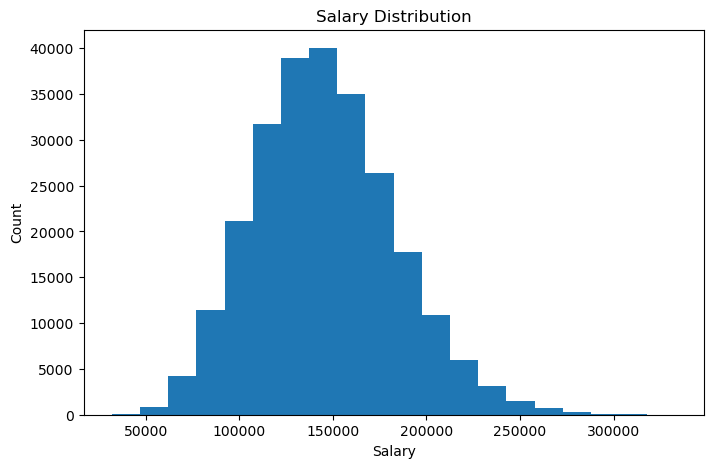

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['salary'], bins=20)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

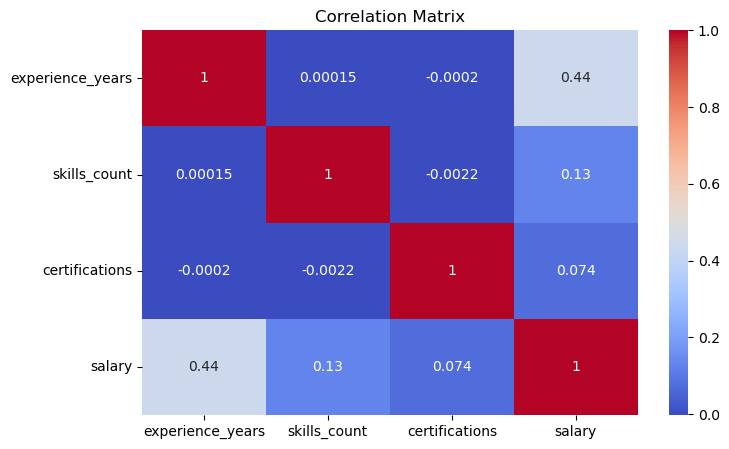

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
X = df.drop("salary", axis=1)
y = df["salary"]

In [12]:
X = pd.get_dummies(X, drop_first=True)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.963469022844696


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


df = pd.read_csv("./datasets/salary-dataset.csv")


df = pd.get_dummies(df, columns=['education_level'], drop_first=True)


feature_cols = ['experience_years', 'skills_count', 'certifications'] + \
               [col for col in df.columns if col.startswith('education_level_')]

X = df[feature_cols]
y = df['salary']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


experience = float(input("Enter Experience (Years): "))
skills = int(input("Enter Skills Count: "))
certifications = int(input("Enter Certifications Count: "))
education = input("Enter Education Level (Bachelor/Master/PhD): ")


input_data = pd.DataFrame(0, index=[0], columns=feature_cols)

input_data['experience_years'] = experience
input_data['skills_count'] = skills
input_data['certifications'] = certifications

edu_col = f"education_level_{education}"
if edu_col in input_data.columns:
    input_data[edu_col] = 1

predicted_salary = model.predict(input_data)[0]


currency = input("Show salary in USD or INR? ").upper()

if currency == "INR":
    salary_in_inr = predicted_salary * 83  
    print(f"Predicted Salary: ₹{salary_in_inr:,.2f}")
else:
    
    print(f"Predicted Salary: ${predicted_salary:,.2f}")